In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
# nlp\Scripts\activate

In [2]:
df = pd.read_parquet('train_tf_idf.parquet')
print('First 5 rows of the DataFrame:')
display(df.head())
print('Label value counts:')
display(df['label'].value_counts())
display(df.info())

sentence_raw = df["sentence"].astype(str).tolist()
labels_raw = df["label"].astype(int).tolist()

First 5 rows of the DataFrame:


,sentence,label,idx
0,"Our friends won't buy this analysis, let alone...",1,0
1,One more pseudo generalization and I'm giving up.,1,1
2,One more pseudo generalization or I'm giving up.,1,2
3,"The more we study verbs, the crazier they get.",1,3
4,Day by day the facts are getting murkier.,1,4


Label value counts:


label
1    6023
0    2528
Name: count, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 8551 entries, 0 to 8550
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sentence  8551 non-null   str  
 1   label     8551 non-null   int64
 2   idx       8551 non-null   int32
dtypes: int32(1), int64(1), str(1)
memory usage: 507.0 KB


None

In [3]:
df[df['label'] == 0]

,sentence,label,idx
18,They drank the pub.,0,18
20,The professor talked us.,0,20
22,We yelled ourselves.,0,22
23,We yelled Harry hoarse.,0,23
25,Harry coughed himself.,0,25
...,...,...,...
8531,Anson believed to be happy.,0,8531
8539,Anson left before Jenny saw himself.,0,8539
8545,Anson thought that himself was going to the club.,0,8545
8546,Poseidon appears to own a dragon,0,8546


In [4]:
# Word stop recognition

from collections import Counter
import unicodedata
import re

def preprocess(text):

    # 1. Normalization and elimination of special characters
    text = str(text).lower()
    text = "".join(text
    )
    #ch for ch in unicodedata.normalize("NFKD", text)
    #    if not unicodedata.combining(ch)

    # 2. Replace all that is not equal to a-z with a space
    text = re.sub(r"[^a-z\s]", " ", text)

    # 3. Split text
    tokens = text.split()

    return " ".join(tokens)

sentence_count_raw = [preprocess(t) for t in sentence_raw]

temporal_tokens = " ".join(sentence_count_raw).split()
frequency = Counter(temporal_tokens)

# Filter: Words with a len <= 3 and its frequency
word_frequency = {word: count for word, count in frequency.items() if len(word) > 3}

# Top words and frequency
m_f = 150
top_word_frequency = Counter(word_frequency).most_common(m_f)
print(f'{m_f} most common words and its frequency:')
print(top_word_frequency)

# Top words
top_words = [word for word, _ in top_word_frequency]
#print(top_words)

150 most common words and its frequency:
[('that', 1283), ('john', 992), ('mary', 478), ('bill', 417), ('will', 397), ('with', 372), ('have', 333), ('more', 328), ('which', 326), ('this', 304), ('they', 284), ('book', 253), ('from', 223), ('what', 217), ('there', 205), ('would', 195), ('than', 187), ('been', 176), ('left', 142), ('every', 140), ('himself', 139), ('some', 137), ('into', 131), ('gave', 126), ('ball', 123), ('leave', 123), ('about', 115), ('student', 112), ('people', 111), ('know', 106), ('said', 105), ('should', 104), ('were', 102), ('girl', 101), ('students', 100), ('read', 99), ('think', 98), ('much', 96), ('picture', 96), ('like', 94), ('believe', 91), ('bought', 90), ('your', 88), ('didn', 88), ('table', 85), ('when', 84), ('believed', 84), ('never', 82), ('made', 80), ('could', 80), ('books', 79), ('fred', 75), ('sent', 74), ('tomorrow', 74), ('sally', 71), ('many', 71), ('seems', 71), ('desk', 71), ('problem', 70), ('eaten', 69), ('before', 69), ('came', 68), ('lik

In [5]:
import unicodedata
import re
from collections import Counter
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("english")

def strip_accents(s: str) -> str:
    return "".join(ch for ch in unicodedata.normalize("NFKD", s) if not unicodedata.combining(ch))

stop_words = {}

#stop_words = {'that', 'john', 'mary', 'bill', 'will', 'with', 'have', 'more', 'which', 'this', 'they', 'book', 'from', 'what', 'there', 'would', 'than',
#                'been', 'left', 'every', 'himself', 'some', 'into', 'gave', 'leave', 'about', 'student', 'people', 'know', 'said', 'should', 'were', 
#                'girl', 'read', 'think', 'much', 'like', 'believe', 'bought', 'your', 'didn', 'when', 'believed', 'never', 'made', 'could', 'fred', 'sent', 
#                'many', 'seems', 'eaten', 'before', 'came', 'likes', 'want', 'everyone', 'might', 'them', 'last', 'went', 'talked', 'taller', 'ever', 'children', 
#                'very', 'their', 'herself', 'whether', 'these', 'does', 'asked', 'over', 'enough', 'easily', 'likely', 'wanted', 'kicked', 'medea', 'give', 'after', 
#                'happy', 'must', 'jason', 'kissed', 'susan', 'believes', 'broke', 'thinks', 'loved', 'going', 'whom', 'here', 'wants', 'tried', 'easy', 'sang', 'anything',
#                'gets', 'eats', 'thought', 'because', 'told', 'down', 'tall', 'knows', 'arrived', 'harry', 'those', 'smith', 'through', 'obvious', 'well', 'just', 'come', 
#                'sandy', 'reading', 'anson'
#}

# Normalize stopwords in the same way we normalize text
stop_words = {strip_accents(w.lower()) for w in stop_words}

min_len_word = 0

def full_preprocess(text):

    # 1. Normalization and elimination of special characters
    text = str(text).lower()
    #text = strip_accents(text)

    # 2. Replace all that is not equal to a-z with a space
    text = re.sub(r"[^a-z\s]", " ", text)

    # 3. Split text
    tokens = text.split()

    # 4. Elimination of stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # 5. Remove the words with length less than or equal to min_len_word
    tokens = [t for t in tokens if len(t) >= min_len_word]

    # 6. Apply Stemming
    #tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(tokens)

sentence_clean = [full_preprocess(t) for t in sentence_raw]

pairs = [(r, c) for r, c in zip(sentence_raw, sentence_clean) if c.strip()]
pairs = [
    (r, c, l) for r, c, l in zip(sentence_raw, sentence_clean, labels_raw) 
    if c.strip()
]
sentence_raw, sentence_clean, labels_clean = zip(*pairs) if pairs else ([], [])
sentence_raw, sentence_clean, labels_clean = list(sentence_raw), list(sentence_clean), list(labels_clean)

print("Docs (clean, non-empty):", len(sentence_clean))
print('Labels (clean, non-empty):', len(labels_clean))
print("Top tokens after preprocessing:", Counter(" ".join(sentence_clean).split()).most_common(20))

Docs (clean, non-empty): 8551
Labels (clean, non-empty): 8551
Top tokens after preprocessing: [('the', 5461), ('to', 2183), ('a', 1372), ('i', 1339), ('that', 1283), ('is', 1110), ('john', 992), ('of', 826), ('he', 747), ('and', 736), ('was', 717), ('in', 712), ('you', 613), ('it', 594), ('mary', 478), ('be', 476), ('who', 468), ('on', 445), ('bill', 417), ('for', 411)]


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Estos parámetros funcionan igual que en CountVectorizer
tfidf_vectorizer = TfidfVectorizer(
    #analyzer='word',
    #max_df=0.95,      # Eliminates the words that appear more than 90% of the documents (Eliminates common or irrelevant words)
    min_df=2,        # Keep words that appear at least in 2 documents (Eliminates weird or stranges words)
    ngram_range=(2, 3) # Contains unigrams and bigrams
)

X_tfidf = tfidf_vectorizer.fit_transform(sentence_clean)
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print("Vocab size TF-IDF:", len(vocab_tfidf))
print(f"Shape of the TF-IDF feature matrix: {X_tfidf.shape}")

Vocab size TF-IDF: 16160
Shape of the TF-IDF feature matrix: (8551, 16160)


In [7]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = X_tfidf
y = labels_clean

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train:", len(y_train))
print(f"Shape of y_test:", len(y_test))

Shape of X_train: (6840, 16160)
Shape of X_test: (1711, 16160)
Shape of y_train: 6840
Shape of y_test: 1711


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Definición del modelo
# penalty='l1' activa Lasso (selección de características)
# solver='liblinear' es necesario para L1
# class_weight='balanced' ajusta pesos para clases desbalanceadas
log_reg = LogisticRegression(
    penalty='l1', 
    solver='liblinear', 
    class_weight='balanced', 
    max_iter=1000
)

# 2. Espacio de búsqueda para el parámetro de regularización C
# C es el inverso de la fuerza de regularización (valores pequeños = más regularización)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# 3. Configuración de la búsqueda con validación cruzada
# Usamos scoring='roc_auc' para que elija el mejor C basándose en esa métrica
grid_search = GridSearchCV(
    estimator=log_reg, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc',
    verbose=1
)

# 4. Entrenamiento
# X_train es tu matriz generada con TfidfVectorizer
grid_search.fit(X_train, y_train)

# 5. Mejores resultados
print(f"Mejor valor de C: {grid_search.best_params_['C']}")
print(f"Mejor ROC-AUC en validación: {grid_search.best_score_:.4f}")

# 6. Evaluación final en test usando probabilidades
best_model = grid_search.best_estimator_
y_probs = best_model.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_probs)

print(f"ROC-AUC final en Test: {auc_test:.4f}")

In [9]:
auc_test = roc_auc_score(y_test, y_probs)

print(f"ROC-AUC final en Test: {auc_test:.4f}")

ROC-AUC final en Test: 0.6061


In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logistic_model = LogisticRegression(random_state=42, solver='liblinear')

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")

Logistic Regression Model Accuracy: 0.7083


### Explanation of Model Evaluation Metrics

After training a classification model, it's essential to evaluate its performance using various metrics beyond just accuracy. These metrics provide a more nuanced understanding of how well the model is performing, especially in cases of imbalanced datasets or when different types of errors have different costs.

**1. AUC (Area Under the Receiver Operating Characteristic Curve)**

*   **What it is**: AUC measures the ability of a classifier to distinguish between classes. It represents the probability that the model ranks a random positive example higher than a random negative example.
*   **Interpretation**: An AUC of 1.0 means the model perfectly distinguishes between positive and negative classes, while an AUC of 0.5 suggests no better performance than random guessing. Higher AUC values are generally better.

**2. Confusion Matrix**

*   **What it is**: A table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It shows the number of correct and incorrect predictions made by the classifier compared to the actual outcomes.
*   **Components**:
    *   **True Positives (TP)**: Correctly predicted positive instances.
    *   **True Negatives (TN)**: Correctly predicted negative instances.
    *   **False Positives (FP)**: Incorrectly predicted positive instances (Type I error).
    *   **False Negatives (FN)**: Incorrectly predicted negative instances (Type II error).
*   **Interpretation**: A good model will have high TP and TN values, and low FP and FN values.

**3. Classification Report**

*   **What it is**: A text-based summary of the precision, recall, f1-score, and support for each class.
*   **Key Metrics**:
    *   **Precision**: The proportion of positive identifications that were actually correct. `Precision = TP / (TP + FP)`.
    *   **Recall (Sensitivity)**: The proportion of actual positives that were identified correctly. `Recall = TP / (TP + FN)`.
    *   **F1-Score**: The harmonic mean of precision and recall. It's a useful metric for imbalanced classes. `F1-Score = 2 * (Precision * Recall) / (Precision + Recall)`.
    *   **Support**: The number of actual occurrences of the class in the specified dataset.
*   **Interpretation**: These metrics help evaluate the model's performance on a per-class basis, which is crucial for understanding where the model might be struggling or performing well.

AUC Score: 0.5095

Confusion Matrix:
[[  12  465]
 [   7 1134]]


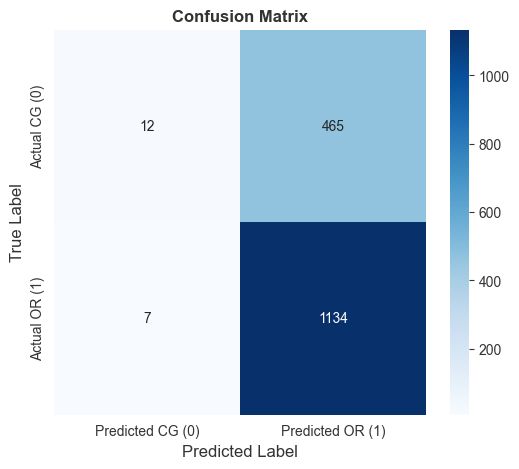


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.03      0.05       477
           1       0.71      0.99      0.83      1141

    accuracy                           0.71      1618
   macro avg       0.67      0.51      0.44      1618
weighted avg       0.69      0.71      0.60      1618



In [107]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate AUC
auc_score = roc_auc_score(y_test, y_pred)
print(f"AUC Score: {auc_score:.4f}")

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plotting the Confusion Matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted CG (0)', 'Predicted OR (1)'],
            yticklabels=['Actual CG (0)', 'Actual OR (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Display Classification Report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

### ROC Plot

This plot visualizes the Receiver Operating Characteristic (ROC) curve for our Logistic Regression model. The ROC curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.

**Key elements of the plot:**

*   **X-axis (False Positive Rate - FPR)**: The proportion of negative cases incorrectly classified as positive.
*   **Y-axis (True Positive Rate - TPR)**: The proportion of positive cases correctly classified as positive (also known as Recall or Sensitivity).
*   **Blue-green line (ROC Curve)**: Represents the trade-off between TPR and FPR at different threshold settings. A curve that bows more towards the top-left corner indicates better performance.
*   **Area Under the Curve (AUC)**: The area under the ROC curve. An AUC of 1.0 represents a perfect classifier, while an AUC of 0.5 (represented by the dashed grey line) indicates a classifier no better than random guessing.

The style is adapted to mimic the clean and professional aesthetic often found in Financial Times graphics, using sans-serif fonts, subtle gridlines, and a minimalist design.

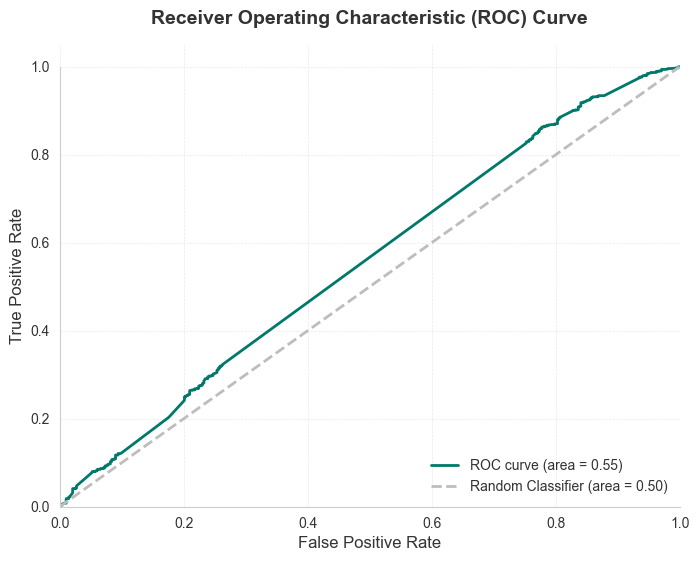

In [108]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Get prediction probabilities for the positive class (class 1)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# --- Financial Times style emulation ---
# Set a clean style
sns.set_style("whitegrid", {"axes.edgecolor": "#cccccc", "grid.color": "#e0e0e0"})
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Lato'], # Common sans-serif fonts
    'axes.titleweight': 'bold',
    'axes.labelweight': 'normal',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'legend.fontsize': 10
})

plt.figure(figsize=(8, 6))

# Plot ROC curve
plt.plot(fpr, tpr, color='#00796B', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

# Plot random classifier line
plt.plot([0, 1], [0, 1], color='#BDBDBD', lw=2, linestyle='--', label='Random Classifier (area = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=15)
plt.legend(loc='lower right', frameon=False)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Remove top and right spines for cleaner look
sns.despine(trim=True)

plt.show()

# Task
Define and train a Decision Tree classifier pipeline using `GridSearchCV` with a parameter grid, evaluate its performance, and present the best parameters and classification report.

## Define and train Decision Tree pipeline

### Subtask:
Set up a pipeline for `DecisionTreeClassifier`, define its parameter grid, and use `GridSearchCV` to find the best model and evaluate its performance.


In [60]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
"Grid Search & Cross Validation"
# 2. Create a Pipeline named dt_pipeline
dt_pipeline = Pipeline([
    ('classifier', DecisionTreeClassifier())
])

# 3. Define a parameter grid named dt_param_grid
dt_param_grid = {
    'classifier__max_depth': [10, 20], # None means no limit on depth
    'classifier__min_samples_leaf': [1, 5]
}

# 4. Initialize GridSearchCV named dt_grid_search
dt_grid_search = GridSearchCV(dt_pipeline, dt_param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# 5. Fit dt_grid_search to the training data
print("Starting GridSearchCV for Decision Tree...")
dt_grid_search.fit(X_train, y_train)
print("GridSearchCV for Decision Tree completed.")

# 6. Print the best parameters found by dt_grid_search
print("\nBest parameters found:", dt_grid_search.best_params_)

# 7. Get the best estimator from dt_grid_search
best_dt_model = dt_grid_search.best_estimator_
print("\nBest Decision Tree Estimator:", best_dt_model)

# 8. Make predictions on the test set using the best estimator
y_pred_dt = best_dt_model.predict(X_test)

# 9. Print the classification_report
print("\nDecision Tree Classification Report (with GridSearchCV):")
print(classification_report(y_test, y_pred_dt))

Starting GridSearchCV for Decision Tree...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
GridSearchCV for Decision Tree completed.

Best parameters found: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1}

Best Decision Tree Estimator: Pipeline(steps=[('classifier', DecisionTreeClassifier(max_depth=10))])

Decision Tree Classification Report (with GridSearchCV):
              precision    recall  f1-score   support

           0       0.35      0.01      0.02       715
           1       0.71      0.99      0.82      1711

    accuracy                           0.70      2426
   macro avg       0.53      0.50      0.42      2426
weighted avg       0.60      0.70      0.59      2426



# Task
Define and train an XGBoost pipeline for classification, including setting up a parameter grid, using `GridSearchCV` to find the best model, and evaluating its performance.

## Define and train XGBoost pipeline

### Subtask:
Set up a pipeline for `XGBClassifier`, define its parameter grid, and use `GridSearchCV` to find the best model and evaluate its performance.


In [ ]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# 2. Create a Pipeline named xgb_pipeline
xgb_pipeline = Pipeline([
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# 3. Define a parameter grid named xgb_param_grid
xgb_param_grid = {
    'classifier__n_estimators': [50],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.1]
}

# 4. Initialize GridSearchCV named xgb_grid_search
xgb_grid_search = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# 5. Fit xgb_grid_search to the training data
print("Starting GridSearchCV for XGBoost...")
xgb_grid_search.fit(X_train, y_train)
print("GridSearchCV for XGBoost completed.")

# 6. Print the best parameters found by xgb_grid_search
print("\nBest parameters found:", xgb_grid_search.best_params_)

# 7. Get the best estimator from xgb_grid_search
best_xgb_model = xgb_grid_search.best_estimator_
print("\nBest XGBoost Estimator:", best_xgb_model)

# 8. Make predictions on the test set using the best estimator
y_pred_xgb = best_xgb_model.predict(X_test)

# 9. Print the classification_report
print("\nXGBoost Classification Report (with GridSearchCV):")
print(classification_report(y_test, y_pred_xgb))

Starting GridSearchCV for XGBoost...
Fitting 3 folds for each of 2 candidates, totalling 6 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:01:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV for XGBoost completed.

Best parameters found: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 50}

Best XGBoost Estimator: Pipeline(steps=[('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
               

# Task
Extract feature names from the `tfidf_vectorizer` object and store them for later use in analyzing feature importances.

## Extract Feature Names

### Subtask:
Extract the feature names (words) from the `tfidf_vectorizer` object, which are needed to interpret the feature importances.


In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"Successfully extracted {len(feature_names)} feature names.")
print("First 10 feature names:", feature_names[:10])

Successfully extracted 5000 feature names.
First 10 feature names: ['00' '000' '10' '100' '1000' '1080p' '11' '12' '120' '13']


## Analyze Decision Tree Feature Importance

### Subtask:
Extract feature importances from the best Decision Tree model, map them to their corresponding words, and identify the top most important words for classification. This will be visualized with a bar plot.


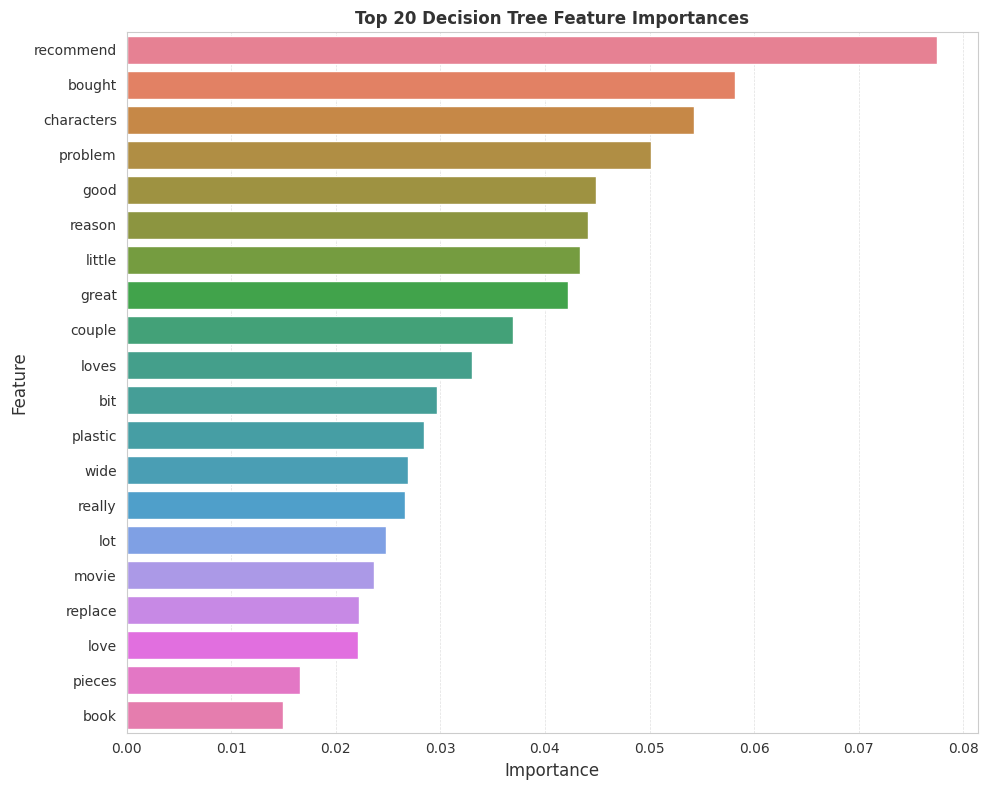

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Temporarily adjust font settings to suppress font warnings
# 'DejaVu Sans' is usually available in Colab environments
original_font_sans_serif = plt.rcParams['font.sans-serif']
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'sans-serif']

# 1. Access feature importances from the best Decision Tree model
dt_feature_importances = best_dt_model.named_steps['classifier'].feature_importances_

# 2. Create a Pandas DataFrame
dt_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_feature_importances
})

# 3. Sort the DataFrame in descending order
dt_feature_importance_df = dt_feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Select the top 20 most important features
top_20_dt_features = dt_feature_importance_df.head(20)

# 5-9. Create a horizontal bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_20_dt_features, hue='Feature', legend=False)
plt.title('Top 20 Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

# 10. Display the plot
plt.show()

# Revert font settings to original if needed for subsequent plots
plt.rcParams['font.sans-serif'] = original_font_sans_serif

## Analyze XGBoost Feature Importance

### Subtask:
Extract feature importances from the best XGBoost model, map them to their corresponding words, and identify the top most important words for classification. This will be visualized with a bar plot.


**Reasoning**:
To analyze the XGBoost feature importance, I need to extract the feature importances from the best model, create a DataFrame, sort it, select the top 20 features, and then visualize them using a horizontal bar plot, while also handling font warnings.



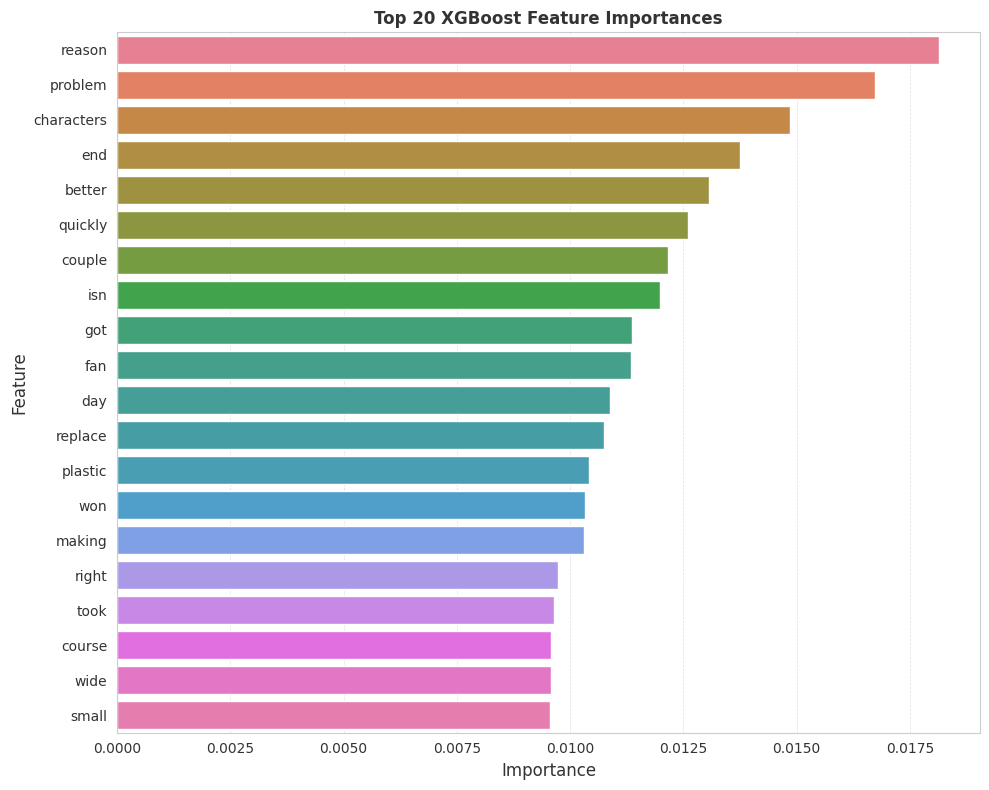

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Temporarily adjust font settings to suppress font warnings
# 'DejaVu Sans' is usually available in Colab environments
original_font_sans_serif = plt.rcParams['font.sans-serif']
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'sans-serif']

# 1. Access feature importances from the best XGBoost model
xgb_feature_importances = best_xgb_model.named_steps['classifier'].feature_importances_

# 2. Create a Pandas DataFrame
xgb_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_feature_importances
})

# 3. Sort the DataFrame in descending order
xgb_feature_importance_df = xgb_feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Select the top 20 most important features
top_20_xgb_features = xgb_feature_importance_df.head(20)

# 5-9. Create a horizontal bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_20_xgb_features, hue='Feature', legend=False)
plt.title('Top 20 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

# 10. Display the plot
plt.show()

# Revert font settings to original if needed for subsequent plots
plt.rcParams['font.sans-serif'] = original_font_sans_serif

## Final Task

### Subtask:
Present the top most important words identified by each model and discuss any insights into how different words contribute to detecting fake or real reviews.


## Summary:

### Data Analysis Key Findings

*   A total of 5000 feature names (words) were successfully extracted from the TF-IDF vectorizer, with examples including '00', '000', '10', and '100'.
*   For the Decision Tree model, the top 20 most important words for classification were identified, and their respective importances were visualized using a bar plot.
*   Similarly, for the XGBoost model, the top 20 most important words contributing to classification were identified, and their importances were visualized.

### Insights or Next Steps

*   Comparing the specific words identified as most important by both the Decision Tree and XGBoost models could reveal which terms consistently influence review classification, providing insights into linguistic patterns indicative of fake or real reviews.
*   Analyzing the context and frequency of these top words in the original review text could further explain their importance and help understand the distinct cues used by each model for classification.
